# 05 - Boomerang Risk Index (BRI) - Corregido
## Proyecto Boomerang - SpaceHACK 2026

Indice compuesto corregido:
- Capa 1: Anomalia NDVI sobre manglar (Landsat 8, ref 2013-2016)
- Capa 2: Presencia de camaronera (clasificacion Sentinel-2)
- Capa 3: Riesgo de marea roja (NDCI + FAI con mascara de agua corregida)

In [20]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np

ee.Initialize(project='august-tower-470819-s6')

In [21]:
# --- ROI ---
roi = ee.Geometry.Polygon([[
    [-80.23433322304784, -2.581044464678974],
    [-80.09837741250097, -2.581044464678974],
    [-80.09837741250097, -2.4212085241315013],
    [-80.23433322304784, -2.4212085241315013],
    [-80.23433322304784, -2.581044464678974]
]])

In [22]:
# ============================================================
# CAPA 1: ANOMALIA NDVI SOBRE MANGLAR
# Usa Landsat 8 consistente, no mezcla de sensores
# Referencia: promedio 2013-2016
# ============================================================

def mask_clouds_l8(image):
    qa = image.select('QA_PIXEL')
    return image.updateMask(qa.bitwiseAnd(1 << 3).eq(0)).updateMask(qa.bitwiseAnd(1 << 4).eq(0))

def process_l8(image):
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    ndvi = optical.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return image.addBands(optical, overwrite=True).addBands(ndvi)

def get_l8_ndvi(year):
    return (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(roi)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUD_COVER', 50))
        .map(mask_clouds_l8).map(process_l8)
        .select('NDVI').median().clip(roi))

# Referencia: promedio 2013-2016
ref = ee.ImageCollection([get_l8_ndvi(y) for y in [2013, 2014, 2015, 2016]]).mean()
ndvi_2024 = get_l8_ndvi(2024)

# Anomalia: negativo = perdida de vigor
anomaly = ndvi_2024.subtract(ref).rename('NDVI_anomaly')

# Normalizar: anomalia negativa -> valores altos (mayor riesgo)
# Clamp entre -0.3 y 0.1, invertir y escalar a 0-1
mangrove_loss = anomaly.multiply(-1).clamp(-0.1, 0.3).subtract(-0.1).divide(0.4).rename('MangroveChange')

print('Capa 1 (MangroveChange): anomalia NDVI 2024 vs ref 2013-2016')

Capa 1 (MangroveChange): anomalia NDVI 2024 vs ref 2013-2016


In [23]:
# ============================================================
# CAPA 2: PRESENCIA DE CAMARONERA
# Sentinel-2 2024
# ============================================================

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2024-01-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .median().clip(roi))

ndvi_s2 = s2.normalizedDifference(['B8', 'B4']).rename('NDVI_S2')
mndwi = s2.normalizedDifference(['B3', 'B11']).rename('MNDWI')

# Camaroneras: NDVI entre 0.0 y 0.3, MNDWI entre -0.3 y 0.3
shrimp_score = (ndvi_s2.gt(0.0).And(ndvi_s2.lt(0.3))
    .And(mndwi.gt(-0.3)).And(mndwi.lt(0.3))).toFloat().rename('ShrimpPresence')

print('Capa 2 (ShrimpPresence): calculada')

Capa 2 (ShrimpPresence): calculada


In [24]:
# ============================================================
# CAPA 3: RIESGO DE MAREA ROJA (mascara de agua CORREGIDA)
# MNDWI > 0.2 + NDVI < 0.3 para excluir vegetacion terrestre
# ============================================================

# Mascara de agua corregida
water_mask = mndwi.gt(0.2).And(ndvi_s2.lt(0.3))

# NDCI
ndci = s2.normalizedDifference(['B5', 'B4']).rename('NDCI')
ndci_norm = ndci.clamp(-0.1, 0.3).subtract(-0.1).divide(0.4)

# FAI
b4 = s2.select('B4').toFloat()
b8 = s2.select('B8').toFloat()
b11 = s2.select('B11').toFloat()
lambda_factor = (832.8 - 664.6) / (1613.7 - 664.6)
fai = b8.subtract(b4.add(b11.subtract(b4).multiply(lambda_factor))).rename('FAI')
fai_norm = fai.clamp(-200, 500).subtract(-200).divide(700)

# Combinar NDCI y FAI (FAI mas confiable, peso 0.6)
red_tide_risk = (ndci_norm.multiply(0.4).add(fai_norm.multiply(0.6))
    .updateMask(water_mask)
    .rename('RedTideRisk'))

print('Capa 3 (RedTideRisk): NDCI+FAI con mascara de agua corregida')

Capa 3 (RedTideRisk): NDCI+FAI con mascara de agua corregida


In [25]:
# ============================================================
# BOOMERANG RISK INDEX (BRI)
# ============================================================

W1 = 0.4  # Perdida de manglar (40%)
W2 = 0.3  # Presencia de camaronera (30%)
W3 = 0.3  # Riesgo de marea roja (30%)

layer1 = mangrove_loss.unmask(0)
layer2 = shrimp_score.unmask(0)
layer3 = red_tide_risk.unmask(0)

bri = (layer1.multiply(W1)
    .add(layer2.multiply(W2))
    .add(layer3.multiply(W3))
    .rename('BRI'))

print(f'BRI calculado con pesos: MangroveChange={W1}, ShrimpPresence={W2}, RedTideRisk={W3}')

BRI calculado con pesos: MangroveChange=0.4, ShrimpPresence=0.3, RedTideRisk=0.3


In [26]:
# --- MAPA DEL BRI ---
bri_vis = {
    'min': 0, 'max': 0.7,
    'palette': ['1a9850', '91cf60', 'fee08b', 'fc4e2a', 'd73027', '67001f']
}

Map_bri = geemap.Map(center=[-2.50, -80.17], zoom=12)
Map_bri.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, 'Sentinel-2 RGB')
Map_bri.addLayer(bri, bri_vis, 'Boomerang Risk Index')

legend_dict = {
    'Riesgo Nulo (0.0-0.1)': '1a9850',
    'Riesgo Bajo (0.1-0.2)': '91cf60',
    'Riesgo Moderado (0.2-0.35)': 'fee08b',
    'Riesgo Alto (0.35-0.5)': 'fc4e2a',
    'Riesgo Critico (0.5-0.7)': 'd73027',
    'Boomerang Activo (>0.7)': '67001f'
}
Map_bri.add_legend(title='Boomerang Risk Index', legend_dict=legend_dict)
Map_bri

Map(center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [27]:
# --- 3 CAPAS INDIVIDUALES ---
Map_layers = geemap.Map(center=[-2.50, -80.17], zoom=12)

Map_layers.addLayer(mangrove_loss, {
    'min': 0, 'max': 0.5,
    'palette': ['white', 'yellow', 'orange', 'red', 'darkred']
}, 'Capa 1: Anomalia Manglar')

Map_layers.addLayer(shrimp_score.selfMask(), {
    'palette': ['FF4500']
}, 'Capa 2: Camaroneras')

Map_layers.addLayer(red_tide_risk, {
    'min': 0, 'max': 0.6,
    'palette': ['blue', 'cyan', 'yellow', 'red']
}, 'Capa 3: Riesgo Marea Roja')

Map_layers

Map(center=[-2.5, -80.17], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [28]:
# --- ALERTAS Y AREAS ---
def calc_area(mask):
    area = mask.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(), geometry=roi, scale=30, maxPixels=1e13
    ).getInfo()
    return list(area.values())[0] / 10000 if area and list(area.values())[0] else 0

area_low = calc_area(bri.gt(0.1).And(bri.lte(0.2)))
area_moderate = calc_area(bri.gt(0.2).And(bri.lte(0.35)))
area_high = calc_area(bri.gt(0.35).And(bri.lte(0.5)))
area_critical = calc_area(bri.gt(0.5))

print('=== DISTRIBUCION DE ALERTAS BRI ===')
print(f'  Riesgo Bajo:      {area_low:>8,.1f} ha')
print(f'  Riesgo Moderado:  {area_moderate:>8,.1f} ha')
print(f'  Riesgo Alto:      {area_high:>8,.1f} ha')
print(f'  Riesgo Critico:   {area_critical:>8,.1f} ha')
total_risk = area_moderate + area_high + area_critical
print(f'\n  Total en riesgo (moderado+): {total_risk:,.1f} ha')

=== DISTRIBUCION DE ALERTAS BRI ===
  Riesgo Bajo:       9,550.5 ha
  Riesgo Moderado:   5,247.1 ha
  Riesgo Alto:       2,600.9 ha
  Riesgo Critico:    1,325.4 ha

  Total en riesgo (moderado+): 9,173.5 ha


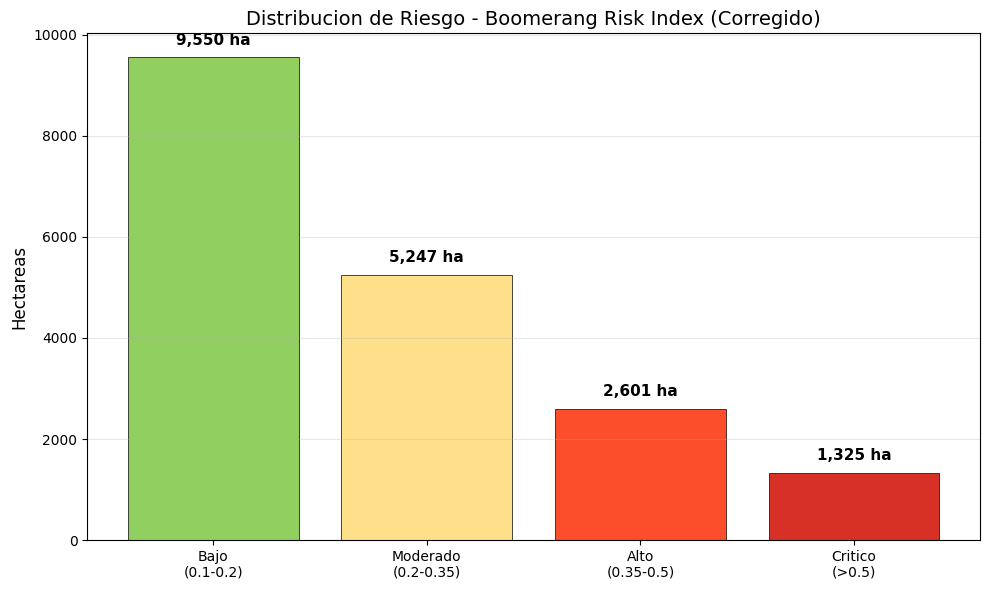

In [29]:
# --- GRAFICA DE DISTRIBUCION ---
categories = ['Bajo\n(0.1-0.2)', 'Moderado\n(0.2-0.35)', 'Alto\n(0.35-0.5)', 'Critico\n(>0.5)']
areas = [area_low, area_moderate, area_high, area_critical]
colors = ['#91cf60', '#fee08b', '#fc4e2a', '#d73027']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, areas, color=colors, edgecolor='black', linewidth=0.5)
for bar, area in zip(bars, areas):
    if area > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(areas)*0.02,
                f'{area:,.0f} ha', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Hectareas', fontsize=12)
ax.set_title('Distribucion de Riesgo - Boomerang Risk Index (Corregido)', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../exports/bri_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# --- ESTADISTICAS BRI ---
bri_stats = bri.reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.max(), sharedInputs=True)
        .combine(ee.Reducer.min(), sharedInputs=True)
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.percentile([25, 50, 75]), sharedInputs=True),
    geometry=roi, scale=30, maxPixels=1e13
).getInfo()

print('=== ESTADISTICAS BRI ===')
for key, val in sorted(bri_stats.items()):
    if val is not None:
        print(f'  {key}: {val:.4f}')

=== ESTADISTICAS BRI ===
  BRI_max: 0.9527
  BRI_mean: 0.1879
  BRI_min: 0.0000
  BRI_p25: 0.0840
  BRI_p50: 0.1465
  BRI_p75: 0.2636
  BRI_stdDev: 0.1484
